In [1]:
import pandas as pd

import pickle

from tqdm.notebook import tqdm

import os
from dotenv import load_dotenv

from IPython.display import display, Markdown

from langchain_openai import ChatOpenAI

import json

import numpy as np

import concurrent.futures
import logging

from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting

from adr import adr
import utils
from adr_classification import ADRClassifier, ClassificationFramework
from adr_classification import ZimmermannEnum, KruchtenEnum, QualityAttributesEnum


---

In [2]:

ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

# logging.basicConfig(stream=sys.stdout, level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

print(load_dotenv())

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_MODEL_NAME"] = 'gpt-4o-mini'
print(os.environ["OPENAI_MODEL_NAME"])

True
gpt-5-nano


In [3]:
# Datasets with examples manually tagged by humans
# QAS_GROUND_TRUTH = './sample/qas_gt_processed1.csv'
QAS_GROUND_TRUTH = './sample/qas_gt_processed1_checked1.csv'

# Datasets of examples for few-shot strategy
QAS_FEW_SHOTS = '../sample/qas_fewshots_raw.json'

---

### Load the Dataset of ADRs

In [4]:
# Configure LLM via Langchain
llm = ChatOpenAI(
      model=os.environ["OPENAI_MODEL_NAME"], temperature=0.0, 
      # callback_manager=CallbackManager([StreamingStdOutCallbackHandler()])
)
# llm.invoke("Tell me a joke about data scientists")

In [5]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


In [6]:
# Select a sample set of ADRs to classify
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

---

### 1. Quality Attribute Framework

In [7]:
# Load ground truth
relative_path = os.path.join('..', QAS_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR', 'raw_text'])
print(df_gt.shape)

# Print the categories (4) covered by the ground truth
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

adr_texts = {row['ADR']: row['raw_text'] for _, row in df_gt.iterrows()}
df_gt.head()

(200, 10)
11 ['Maintainability' 'Compatibility' 'Other/Only Functional Concern'
 'Performance' 'Security' 'Scalability' 'Observability' 'Usability'
 'Testability' 'Reliability' 'Portability']
11 ['Maintainability' 'Other/Only Functional Concern' 'Testability'
 'Performance' 'Security' 'Observability' 'Compatibility' 'Scalability'
 'Portability' 'Reliability' 'Usability']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Human-old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Maintainability,The ADR discusses implementing an architectura...,"0,75",Maintainability,Maintainability,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Maintainability,The ADR discusses using Ansible roles and play...,"0,60",Compatibility,Compatibility,0.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Other/Only Functional Concern,The ADR primarily discusses versioning and rel...,"0,30",Other/Only Functional Concern,Other/Only Functional Concern,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Maintainability,The ADR primarily addresses how configuration ...,"0,75",Maintainability,Maintainability,1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Testability,The ADR primarily discusses procedural and ope...,"0,20",Maintainability,Maintainability,0.0,# Cutting release branch does not create a set...


In [8]:
labels = sorted([str(member.value) for member in QualityAttributesEnum])
print(len(labels), labels)

# Encoding target
# le = LabelEncoder()
# encoding = le.fit_transform(labels)


11 ['Compatibility', 'Maintainability', 'Observability', 'Other/Only Functional Concern', 'Performance', 'Portability', 'Reliability', 'Scalability', 'Security', 'Testability', 'Usability']


In [9]:
# Get a particular (random) ADR from the ground truth to test classification
adr_example = df_gt['raw_text'].tolist()[8]
# adr_example = list(adr_texts.values())[8]
adr_example

"# Web Application\n\n**Status:** Accepted\n\n## Context\n\nWe need an application platform that meets the following requirements:\n\n- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.\n- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.\n\n### Option 1 - Cache First Web App (PWA)\n\nBy creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.\n\n### Option 2 - Native application\n\nAnother option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed m

#### Zero-shot Strategy

In [10]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.QUALITY_ATTRIBUTES, include_examples=False)

{"asctime": "2026-01-06 09:34:16,254", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: quality_attributes, include_examples=False"}


In [11]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
The categories refer to referenced or implied quality attributes (non-functional requirements) of a system. 
Use the category definitions, guidelines and rules provided below, derived from ISO/IEC 25010 and the Bass/Clements/Kazman (Software Engineering Institute) framework for quality attributes.
Keep in mind that the quality attributes should refer to the *system being built* rather than to the *process or environment to develop the system*.

## Categories:
- **Performance**: The degree to which a system performs its functions within specified time and throughput parameters, efficiently utilizing resources such as CPU, memory, and storage. 
- **Reliability**: The degree to which a system performs specified functions under stated conditions for a specified period, encompassing attributes like fault tolerance and recoverability. 

In [12]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-06 09:34:16,449", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "quality_attributes",
    "primary_category": "Reliability",
    "explanation": "The ADR focuses on ensuring the application works offline and remains usable under intermittent connectivity, with emphasis on minimizing data loss and maintaining operation on boats with poor internet access. This centers on reliability (offline resilience, fault tolerance and recoverability). The decision also highlights cross-platform reach (Portability) and performance considerations (speed) as secondary factors, but the primary concern is reliable operation under constrained connectivity.",
    "primary_score": 0.72,
    "alternative_categories": [
        "Portability",
        "Performance"
    ],
    "alternative_confidence_scores": [
        0.14,
        0.14
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [13]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_zero_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/qas_gt_processed1_checked1_zero_shot_results.json
Evaluating on ground truth with 200 ADRs.
Saving results to JSON file (for later processing) .././sample/qas_gt_processed1_checked1_zero_shot_results.json


In [14]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=11)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=11)

In [15]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Other/Only Functional Concern', 'Portability', 'Observability', 'Usability', 'Security', 'Testability', 'Maintainability', 'Scalability', 'Performance', 'Compatibility', 'Reliability']

Matthews Coefficient: 0.33376194911416585
Similarities with GT (%): 43.0
Kappa agreement with GT: 0.3291750029422149


{'Compatibility': 0.049429657794676785,
 'Maintainability': 0.30580490724117293,
 'Observability': 0.14383561643835618,
 'Other/Only Functional Concern': 0.24570997548557427,
 'Performance': 0.47916666666666663,
 'Portability': 0.08854166666666663,
 'Reliability': 0.3736951983298539,
 'Scalability': 0.2024539877300614,
 'Security': 0.5703764320785598,
 'Testability': 0.4849785407725322,
 'Usability': 0.32789246279404705}

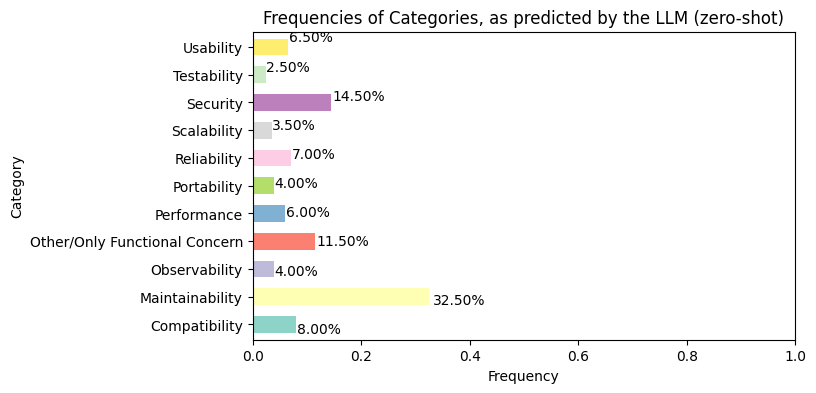

In [16]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (zero-shot)"
_ = utils.show_target_frequencies(pd.Series(target_values), title=title) #, encoding=encoding)

# Note: Compatibility is missing in the LLM predictions

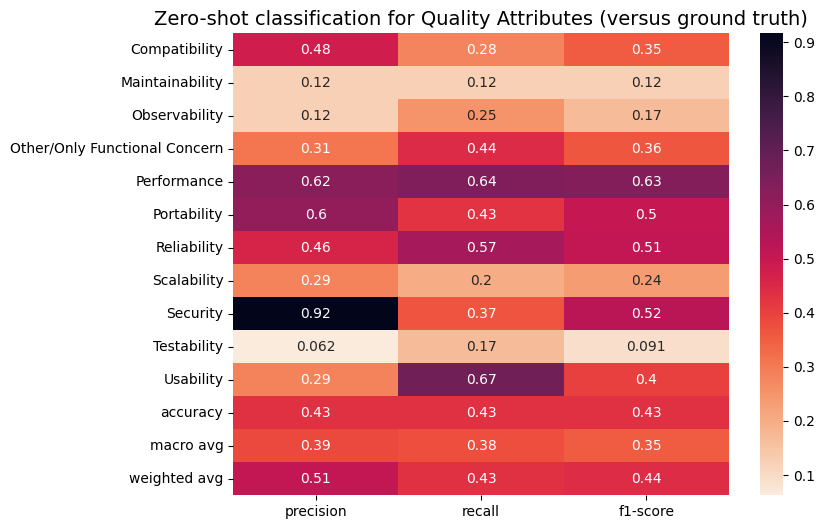

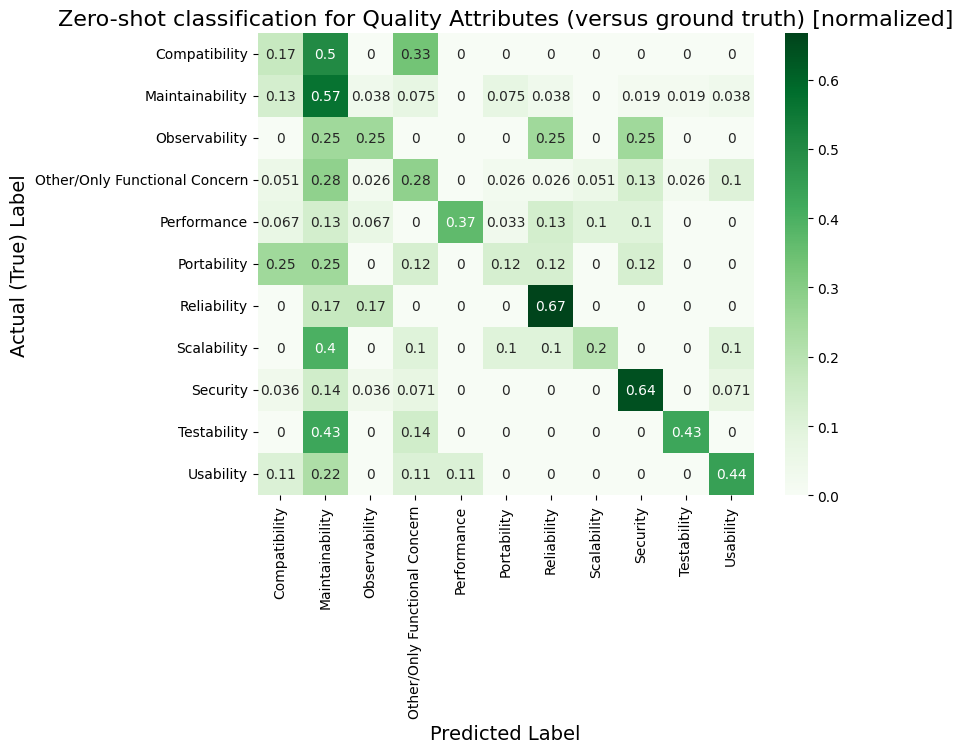

In [17]:
title = "Zero-shot classification for Quality Attributes (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

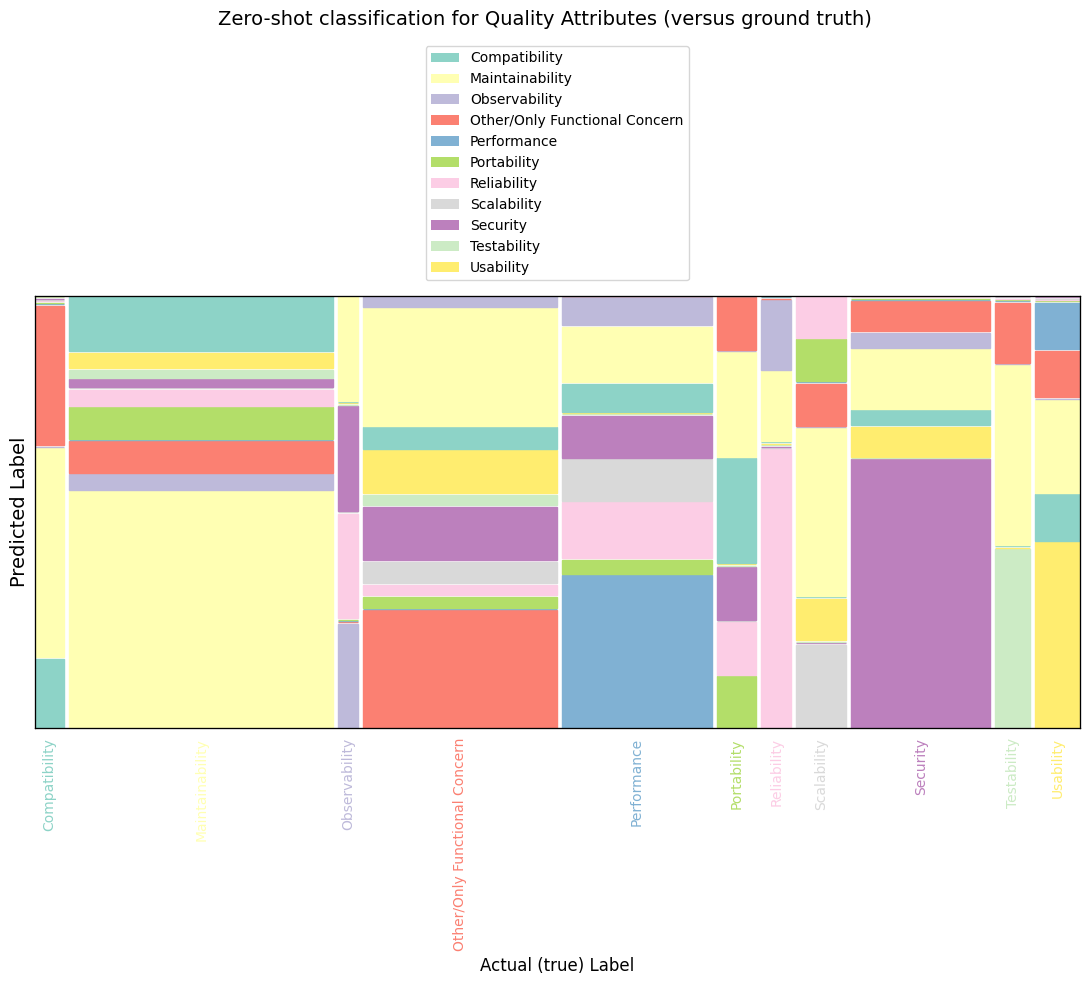

In [18]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
my_colors = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, title=title) #labels=output_dict['labels'])

In [19]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=11)

Differences with GT: 114


[(('Other/Only Functional Concern', 'Maintainability'), 11),
 (('Maintainability', 'Compatibility'), 7),
 (('Other/Only Functional Concern', 'Security'), 5),
 (('Maintainability', 'Other/Only Functional Concern'), 4),
 (('Scalability', 'Maintainability'), 4),
 (('Performance', 'Reliability'), 4),
 (('Performance', 'Maintainability'), 4),
 (('Maintainability', 'Portability'), 4),
 (('Security', 'Maintainability'), 4),
 (('Other/Only Functional Concern', 'Usability'), 4),
 (('Compatibility', 'Maintainability'), 3)]

In [20]:
# Filter specific cases of differences with GT
# true_categories = ['Other/Only Functional Concern', 'Maintainability']
# pred_categories = ['Other/Only Functional Concern', 'Maintainability']

# print(10*'--')
# for idx, cat_true, cat_pred, adr in output_dict['differences']:
#     if cat_true in true_categories and cat_pred in pred_categories:
#         print(cat_true, "vs.", cat_pred, "->", idx, adr)
#         print(10*'--')


#### Few-shot Strategy (static)

In [21]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.QUALITY_ATTRIBUTES, include_examples=True)

{"asctime": "2026-01-06 09:38:24,772", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: quality_attributes, include_examples=True"}


In [22]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
The categories refer to referenced or implied quality attributes (non-functional requirements) of a system. 
Use the category definitions, guidelines, rules and examples provided below, derived from ISO/IEC 25010 and the Bass/Clements/Kazman (Software Engineering Institute) framework for quality attributes.
Keep in mind that the quality attributes should refer to the *system being built* rather than to the *process or environment to develop the system*.

## Categories:
- **Performance**: The degree to which a system performs its functions within specified time and throughput parameters, efficiently utilizing resources such as CPU, memory, and storage.
    + e.g., the decision is primarily motivated by response time, throughput, resource usage. 
- **Reliability**: The degree to which a system performs specified functions under sta

In [23]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-06 09:38:24,851", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "quality_attributes",
    "primary_category": "Portability",
    "explanation": "The ADR chooses to implement a web-based application (PWA) to run across multiple devices (phones, tablets, desktops) with offline capability, prioritizing cross-platform accessibility and deployment simplicity over native platform specialization. This focus aligns with portability (environment/platform independence). Offline considerations touch reliability but are secondary to the cross-platform portability goal.",
    "primary_score": 0.58,
    "alternative_categories": [
        "Reliability",
        "Performance"
    ],
    "alternative_confidence_scores": [
        0.26,
        0.16
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [24]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_static_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/qas_gt_processed1_checked1_static_few_shot_results.json
Evaluating on ground truth with 200 ADRs.
Saving results to JSON file (for later processing) .././sample/qas_gt_processed1_checked1_static_few_shot_results.json


In [25]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=11)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=11)

In [26]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Other/Only Functional Concern', 'Portability', 'Observability', 'Usability', 'Security', 'Testability', 'Maintainability', 'Scalability', 'Performance', 'Compatibility', 'Reliability']

Matthews Coefficient: 0.332063098995225
Similarities with GT (%): 42.0
Kappa agreement with GT: 0.3257773902935194


{'Compatibility': 0.11986588432523049,
 'Maintainability': 0.29802955665024633,
 'Observability': 0.129746835443038,
 'Other/Only Functional Concern': 0.31813339015555087,
 'Performance': 0.40334128878281617,
 'Portability': 0.23822714681440438,
 'Reliability': 0.19354838709677413,
 'Scalability': 0.1578947368421053,
 'Security': 0.5967741935483871,
 'Testability': 0.3470149253731344,
 'Usability': 0.3687532877432931}

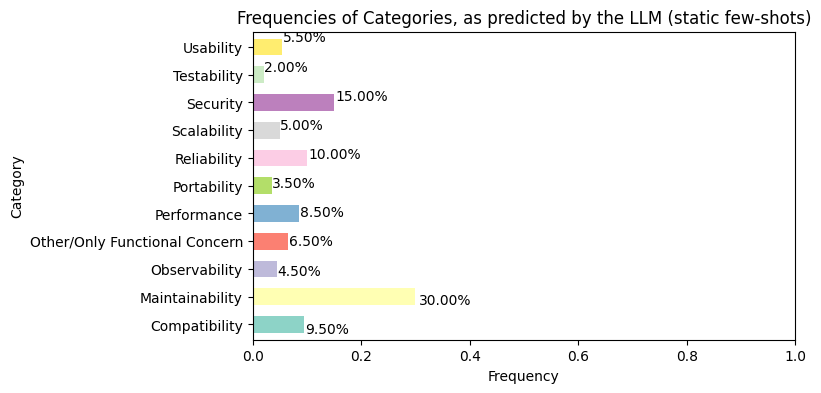

In [27]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (static few-shots)"
_ = utils.show_target_frequencies(pd.Series(target_values), color_dict=my_colors, title=title) #, encoding=encoding)
# Note that compatibility is missing in the LLM predictions

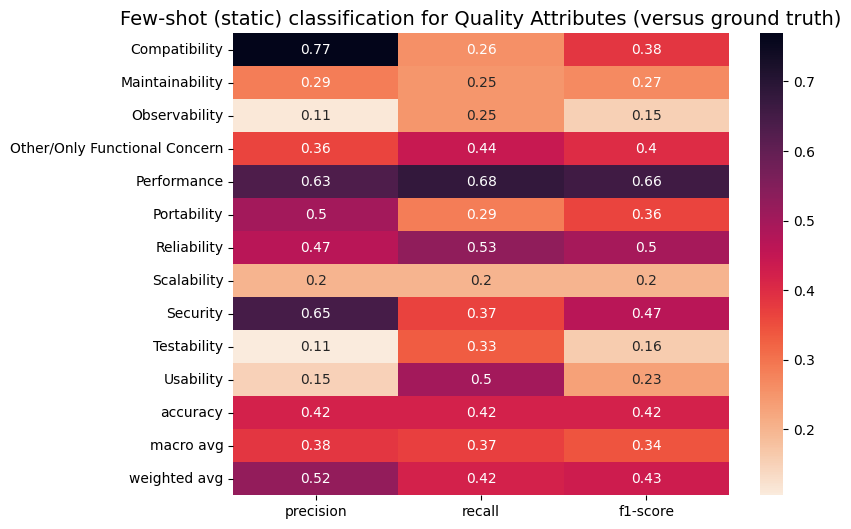

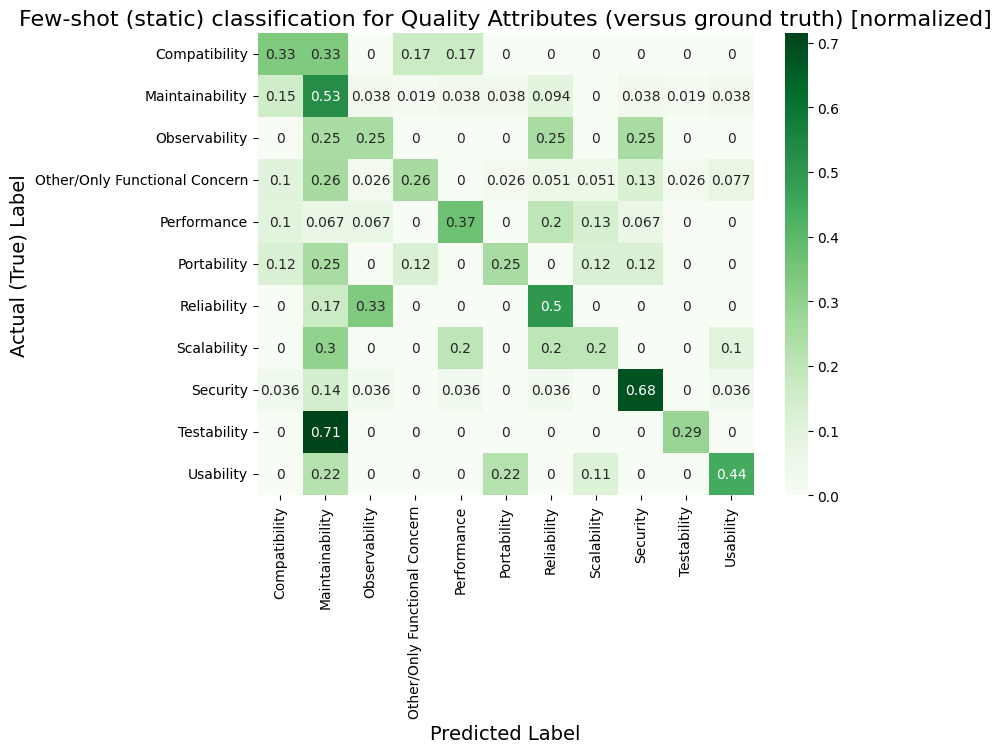

In [28]:
title = "Few-shot (static) classification for Quality Attributes (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

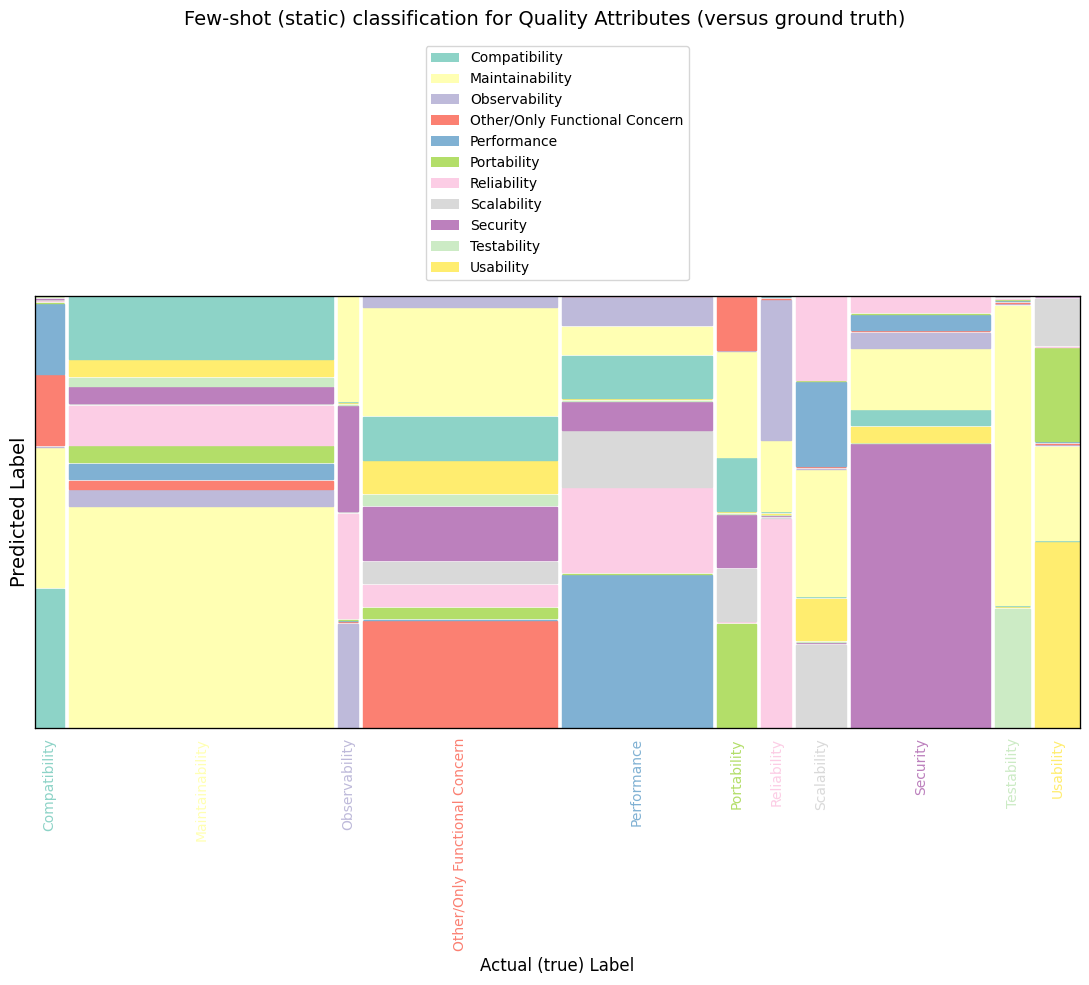

In [29]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [30]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=11)

Differences with GT: 116


[(('Other/Only Functional Concern', 'Maintainability'), 10),
 (('Maintainability', 'Compatibility'), 8),
 (('Performance', 'Reliability'), 6),
 (('Testability', 'Maintainability'), 5),
 (('Other/Only Functional Concern', 'Security'), 5),
 (('Maintainability', 'Reliability'), 5),
 (('Other/Only Functional Concern', 'Compatibility'), 4),
 (('Performance', 'Scalability'), 4),
 (('Security', 'Maintainability'), 4),
 (('Scalability', 'Maintainability'), 3),
 (('Performance', 'Compatibility'), 3)]

#### Few-shot Strategy (dynamic)

In [31]:
with open(QAS_FEW_SHOTS, mode='r') as file:
        # The 'data' variable will be a Python list of dictionaries
        adr_examples = json.load(file)
# adr_examples

In [32]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.QUALITY_ATTRIBUTES, include_examples=True, examples=adr_examples, k=7)

{"asctime": "2026-01-06 09:42:29,847", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: quality_attributes, include_examples=True"}


In [33]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
The categories refer to referenced or implied quality attributes (non-functional requirements) of a system. 
Use the category definitions, guidelines and rules provided below, derived from ISO/IEC 25010 and the Bass/Clements/Kazman (Software Engineering Institute) framework for quality attributes.
Keep in mind that the quality attributes should refer to the *system being built* rather than to the *process or environment to develop the system*.

## Categories:
- **Performance**: The degree to which a system performs its functions within specified time and throughput parameters, efficiently utilizing resources such as CPU, memory, and storage. 
- **Reliability**: The degree to which a system performs specified functions under stated conditions for a specified period, encompassing attributes like fault tolerance and recoverability. 
- **Sec

In [34]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-06 09:42:42,154", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "quality_attributes",
    "primary_category": "Reliability",
    "explanation": "The ADR centers on enabling offline capability for the web app (PWA) to maintain usability despite connectivity issues, which directly targets reliability and fault tolerance of the system. The cross\u2011platform aspect adds portability but is secondary to the goal of functioning reliably when offline or with intermittent connections.",
    "primary_score": 0.72,
    "alternative_categories": [
        "Portability",
        "Performance",
        "Usability"
    ],
    "alternative_confidence_scores": [
        0.12,
        0.1,
        0.06
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [35]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_dynamic_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/qas_gt_processed1_checked1_dynamic_few_shot_results.json
Evaluating on ground truth with 200 ADRs.


ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': 'zindex-values.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': 'adr-067-mempool-refactor.md'}


Saving results to JSON file (for later processing) .././sample/qas_gt_processed1_checked1_dynamic_few_shot_results.json


In [36]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=4)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=11)

{"asctime": "2026-01-06 09:48:07,743", "levelname": "WARNING", "name": "adr_classification", "message": "Dropping 2 as they are not part of the LLM results. ['zindex-values.md', 'adr-067-mempool-refactor.md']"}


In [37]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Other/Only Functional Concern', 'Portability', 'Observability', 'Usability', 'Security', 'Testability', 'Maintainability', 'Scalability', 'Performance', 'Compatibility', 'Reliability']

Matthews Coefficient: 0.4117416202942345
Similarities with GT (%): 50.0
Kappa agreement with GT: 0.4093470334769639


{'Compatibility': -0.03125,
 'Maintainability': 0.35492525871981606,
 'Observability': 0.1602262016965128,
 'Other/Only Functional Concern': 0.36637259989621174,
 'Performance': 0.5286895514908545,
 'Portability': 0.21842105263157896,
 'Reliability': 0.37341772151898733,
 'Scalability': 0.2021078735275884,
 'Security': 0.6859635210150674,
 'Testability': 0.34684260131950995,
 'Usability': 0.5582329317269077}

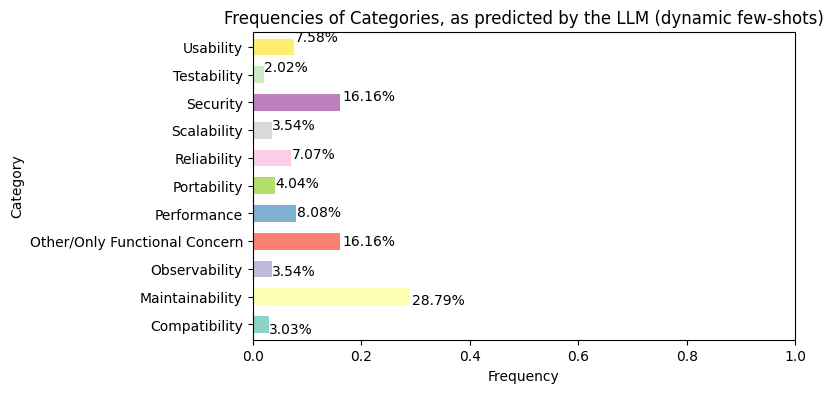

In [38]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (dynamic few-shots)"
_ = utils.show_target_frequencies(pd.Series(target_values), color_dict=my_colors, title=title) #, encoding=encoding)
# Note: Compatibility is missing in the LLM predictions

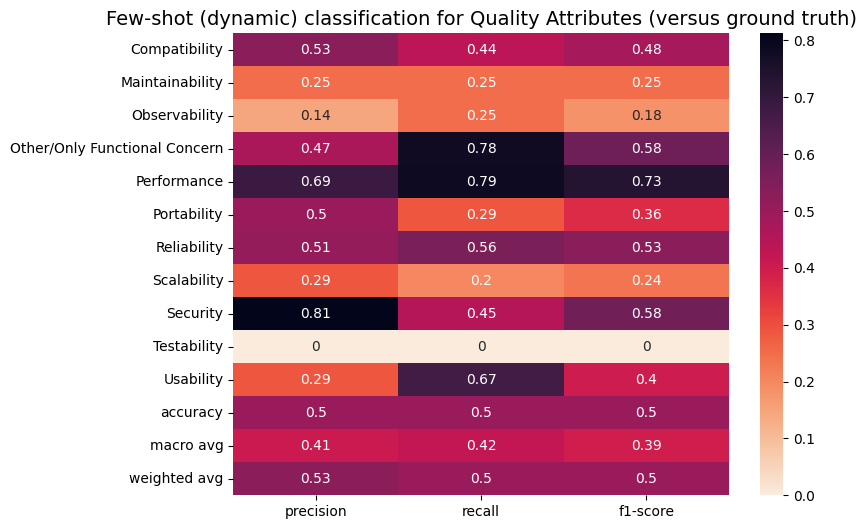

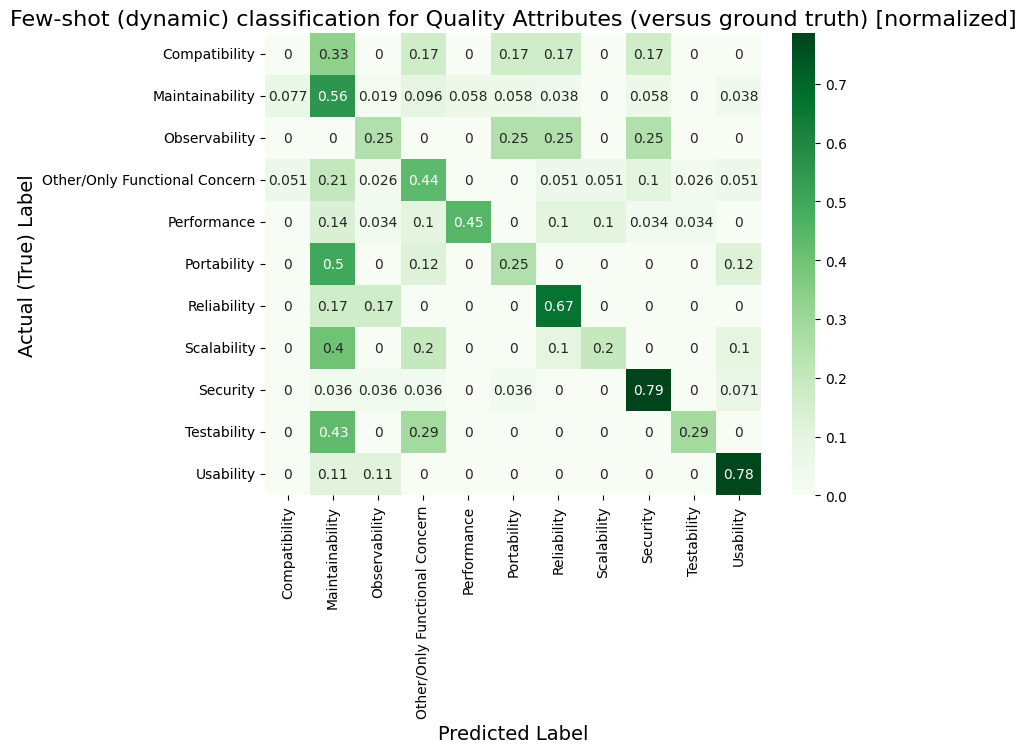

In [39]:
title = "Few-shot (dynamic) classification for Quality Attributes (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

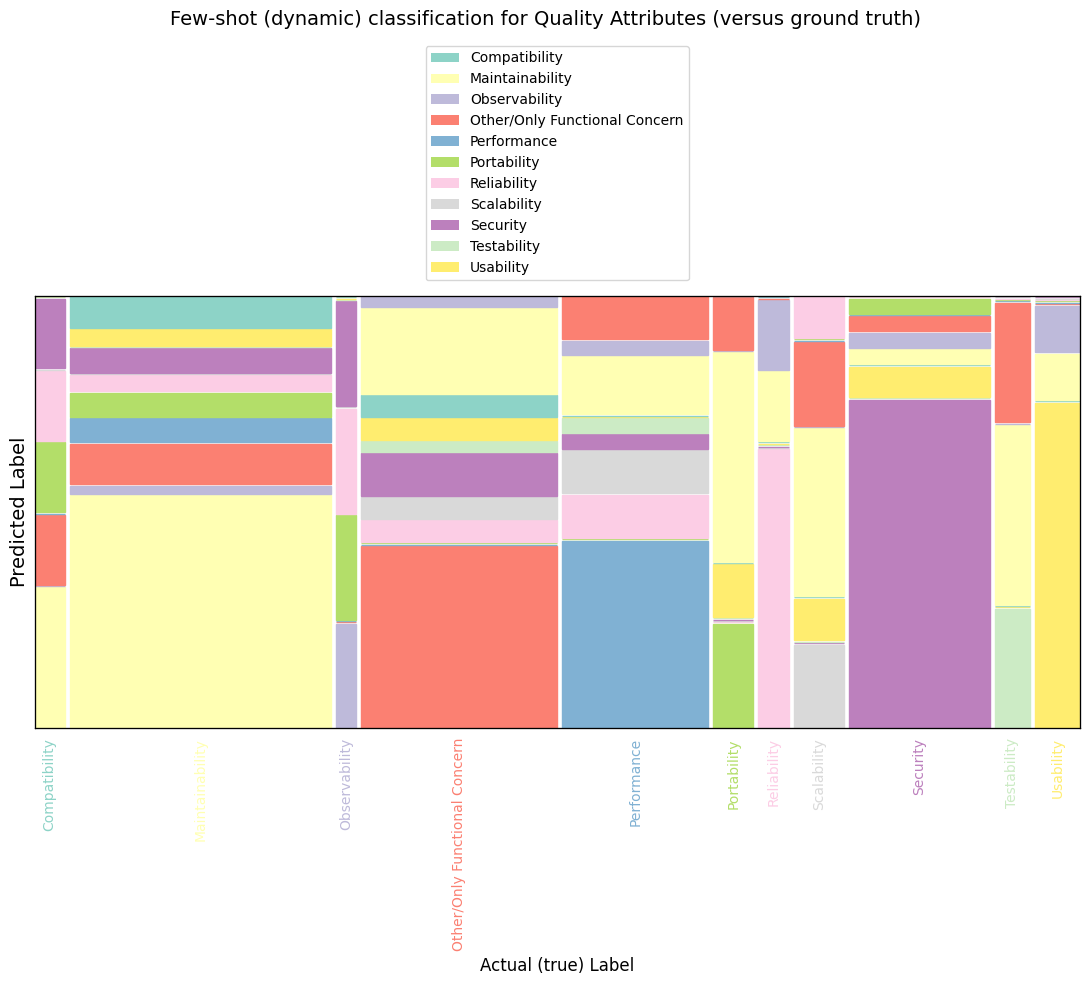

In [40]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [41]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=11)

Differences with GT: 99


[(('Other/Only Functional Concern', 'Maintainability'), 8),
 (('Maintainability', 'Other/Only Functional Concern'), 5),
 (('Scalability', 'Maintainability'), 4),
 (('Maintainability', 'Compatibility'), 4),
 (('Performance', 'Maintainability'), 4),
 (('Portability', 'Maintainability'), 4),
 (('Other/Only Functional Concern', 'Security'), 4),
 (('Maintainability', 'Portability'), 3),
 (('Performance', 'Reliability'), 3),
 (('Performance', 'Other/Only Functional Concern'), 3),
 (('Maintainability', 'Security'), 3)]

---

In [42]:
# TODO: Run the dynamic few-shots strategy on the FULL set of ADRs (there's no ground truth for all of them)